In [205]:
import pandas as pd 

df0 = pd.read_csv("prices_round_1_day_0.csv", sep=';')
df1 = pd.read_csv("prices_round_1_day_-1.csv", sep=';')
df2 = pd.read_csv("prices_round_1_day_-2.csv", sep=';')
df1['timestamp'] = df1['timestamp'] + int(1e6)
df0['timestamp'] = df0['timestamp'] + int(2e6)
df = pd.concat([
                df2, 
                df1, 
                df0
                ])

In [206]:
df[df['bid_price_1'] > 0]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0
5,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19993,0,2999600,ASH_COATED_OSMIUM,10000.0,14.0,9997.0,27.0,NaN,NaN,10016.0,14.0,10018.0,27.0,NaN,NaN,10008.0,0.0
19994,0,2999700,ASH_COATED_OSMIUM,10000.0,11.0,9997.0,24.0,NaN,NaN,10016.0,11.0,10018.0,24.0,NaN,NaN,10008.0,0.0
19995,0,2999700,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,20.0,NaN,NaN,12998.0,0.0
19998,0,2999900,ASH_COATED_OSMIUM,9998.0,21.0,NaN,NaN,NaN,NaN,10016.0,12.0,10019.0,21.0,NaN,NaN,10007.0,0.0


In [207]:
df.shape

(60000, 17)

In [208]:
df_ash = df[df['product'] == 'ASH_COATED_OSMIUM']
df_pepper =  df[df['product'] == 'INTARIAN_PEPPER_ROOT']

In [209]:
df_pepper[df_pepper['bid_price_2'] == 9990]['bid_volume_2'].unique()

array([], dtype=float64)

In [210]:
print(df_pepper['ask_volume_1'].unique())
print(df_pepper['bid_volume_1'].unique())

[ 9. 11. 20. 10. 12. 16.  8. 17. 19. 22. 23. nan 15.  7.  5. 24. 25. 21.
  3. 18.  6.  4.  1.]
[17. 11. 12. nan 20. 23. 21.  9. 10. 24.  8. 19. 22. 15.  7. 16.  5. 18.
 25.  4.  6.  3.  2.]


In [211]:
print("Shape of tomates:", df_ash.shape)
print("Shape of emeralds:", df_pepper.shape)

Shape of tomates: (30000, 17)
Shape of emeralds: (30000, 17)


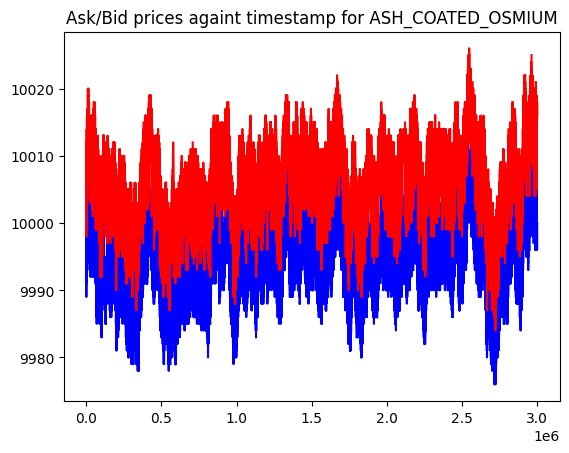

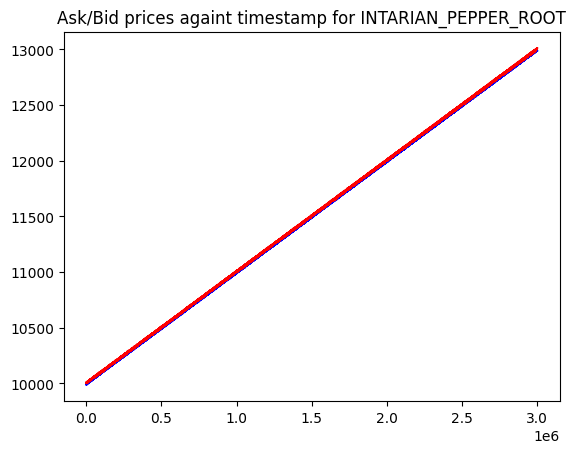

In [212]:
import matplotlib.pyplot as plt

def plot_prices(df, asset):
    x = df['timestamp']
    bid1 = df['bid_price_1']
    ask1 = df['ask_price_1']
    # plt.figure()
    plt.title(label=f"Ask/Bid prices againt timestamp for {asset}")
    plt.plot(x, bid1, color='blue')
    plt.plot(x, ask1, color='red')
    plt.show()

plot_prices(df_ash, "ASH_COATED_OSMIUM")
plot_prices(df_pepper, "INTARIAN_PEPPER_ROOT")


In [213]:
df_ash_10010 = df[
    (df['product'] == 'ASH_COATED_OSMIUM')
    & ~df[['ask_price_1', 'ask_price_2', 'ask_price_3']].eq(10010).any(axis=1)
]

In [214]:
df_ash_10010.head(100)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
14,-2,700,ASH_COATED_OSMIUM,9990.0,27.0,NaN,NaN,NaN,NaN,10011.0,27.0,NaN,NaN,NaN,NaN,10000.5,0.0
16,-2,800,ASH_COATED_OSMIUM,9993.0,15.0,NaN,NaN,NaN,NaN,10011.0,21.0,NaN,NaN,NaN,NaN,10002.0,0.0
19,-2,900,ASH_COATED_OSMIUM,9993.0,13.0,9990.0,30.0,NaN,NaN,9998.0,8.0,10009.0,13.0,10011.0,30.0,9995.5,0.0
20,-2,1000,ASH_COATED_OSMIUM,9990.0,22.0,NaN,NaN,NaN,NaN,10009.0,15.0,10011.0,22.0,NaN,NaN,9999.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,-2,10800,ASH_COATED_OSMIUM,10000.0,11.0,9998.0,22.0,NaN,NaN,10016.0,11.0,10019.0,22.0,NaN,NaN,10008.0,0.0
218,-2,10900,ASH_COATED_OSMIUM,10001.0,15.0,9998.0,21.0,NaN,NaN,10019.0,21.0,NaN,NaN,NaN,NaN,10010.0,0.0
221,-2,11000,ASH_COATED_OSMIUM,10001.0,13.0,9998.0,27.0,NaN,NaN,10017.0,13.0,10019.0,27.0,NaN,NaN,10009.0,0.0
223,-2,11100,ASH_COATED_OSMIUM,10001.0,11.0,NaN,NaN,NaN,NaN,10017.0,11.0,10019.0,29.0,NaN,NaN,10009.0,0.0


In [215]:
df_ash['bid_price_1'][1].values[0]

np.float64(nan)

In [216]:
import numpy as np
df_ash.loc[np.isnan(df_ash['ask_price_1'])].head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
33,-2,1600,ASH_COATED_OSMIUM,9994.0,15.0,9991.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9994.0,0.0
112,-2,5600,ASH_COATED_OSMIUM,9996.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9996.0,0.0
131,-2,6500,ASH_COATED_OSMIUM,9993.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9993.0,0.0
258,-2,12900,ASH_COATED_OSMIUM,10001.0,10.0,9999.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001.0,0.0
295,-2,14700,ASH_COATED_OSMIUM,10000.0,15.0,9997.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000.0,0.0


In [217]:
import pandas as pd 

df0 = pd.read_csv("trades_round_1_day_0.csv", sep=';')
df1 = pd.read_csv("trades_round_1_day_-1.csv", sep=';')
df2 = pd.read_csv("trades_round_1_day_-2.csv", sep=';')
df1['timestamp'] = df1['timestamp'] + int(1e6)
df0['timestamp'] = df0['timestamp'] + int(2e6)
df = pd.concat([df1, df2])

In [218]:
df.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,1002800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9985.0,10
1,1003000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10999.0,8
2,1004200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10995.0,4
3,1005200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10004.0,6
4,1005200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9986.0,9


In [219]:
df_pepper = df[df['symbol'] == "EMERALDS"]

In [220]:
df_pepper_buy = df_pepper[df_pepper['price'] < 10000]
df_pepper_sell = df_pepper[df_pepper['price'] > 10000]

In [221]:
df_pepper_buy.head()

,timestamp,buyer,seller,symbol,currency,price,quantity


In [222]:
print(df_pepper_buy['quantity'].unique())
print(df_pepper_sell['quantity'].unique())

[]
[]


In [223]:
print(df_pepper_buy['price'].value_counts())
print(df_pepper_sell['price'].value_counts())


Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [224]:
df_ash.head(20)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
5,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0
6,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0
8,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0
11,-2,500,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,30.0,NaN,NaN,10008.0,13.0,10010.0,30.0,NaN,NaN,10000.0,0.0
12,-2,600,ASH_COATED_OSMIUM,9989.0,30.0,NaN,NaN,NaN,NaN,10010.0,30.0,NaN,NaN,NaN,NaN,9999.5,0.0
14,-2,700,ASH_COATED_OSMIUM,9990.0,27.0,NaN,NaN,NaN,NaN,10011.0,27.0,NaN,NaN,NaN,NaN,10000.5,0.0
16,-2,800,ASH_COATED_OSMIUM,9993.0,15.0,NaN,NaN,NaN,NaN,10011.0,21.0,NaN,NaN,NaN,NaN,10002.0,0.0
19,-2,900,ASH_COATED_OSMIUM,9993.0,13.0,9990.0,30.0,NaN,NaN,9998.0,8.0,10009.0,13.0,10011.0,30.0,9995.5,0.0


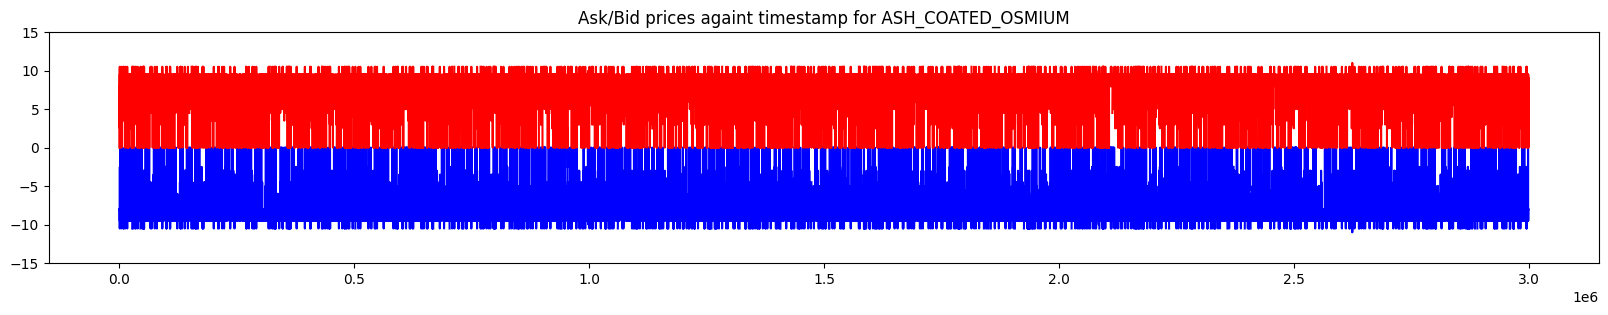

In [225]:
import warnings

def plot_mr(df, asset):
    x = df['timestamp']
    bid1 = df['d_bid_price_1']
    ask1 = df['d_ask_price_1']
    mid = df['d_mid_price']
    plt.figure(figsize=(20, 3))
    plt.title(label=f"Ask/Bid prices againt timestamp for {asset}")
    plt.plot(x, bid1, color='blue')
    plt.plot(x, ask1, color='red')
    # plt.plot(x, mid, color='green')

    plt.ylim(-15, 15)
    plt.show()
window = 5
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df_ash["ma"] = df_ash["mid_price"].rolling(window=window).mean()
    df_ash["d_bid_price_1"] = df_ash["bid_price_1"] - df_ash["mid_price"]
    df_ash["d_ask_price_1"] = df_ash["ask_price_1"] - df_ash["mid_price"]
    df_ash["d_mid_price"] = df_ash["mid_price"] - df_ash["ma"]
import matplotlib.pyplot as plt

plot_mr(df_ash, "ASH_COATED_OSMIUM")

In [226]:
df_ash["shift_mid_price"] = df_ash['mid_price'] - df_ash['mid_price'].shift(1)

In [227]:
df_ash['shift_mid_price'].unique()

array([         nan, -1.00000e+01,  0.00000e+00, -5.00000e-01,
        1.00000e+00,  1.50000e+00, -6.50000e+00,  4.00000e+00,
        8.00000e+00, -1.50000e+00, -8.00000e+00,  1.05000e+01,
       -2.50000e+00,  3.50000e+00, -4.00000e+00, -1.00000e+00,
        2.00000e+00, -2.00000e+00,  6.50000e+00, -1.20000e+01,
       -3.50000e+00,  5.00000e-01,  2.50000e+00, -4.50000e+00,
       -1.10000e+01,  1.10000e+01,  5.00000e+00,  5.50000e+00,
        3.00000e+00,  4.50000e+00, -7.00000e+00,  9.00000e+00,
       -9.50000e+00, -6.00000e+00, -9.00000e+00, -1.40000e+01,
       -5.00000e+00,  7.00000e+00, -1.05000e+01, -5.50000e+00,
        7.50000e+00,  6.00000e+00, -3.00000e+00, -8.50000e+00,
       -1.00040e+04,  1.00050e+04,  8.50000e+00,  1.00000e+01,
       -1.00030e+04,  1.00140e+04, -2.10000e+01, -1.15000e+01,
       -1.00060e+04,  9.99500e+03,  9.50000e+00,  1.15000e+01,
       -1.55000e+01,  1.60000e+01, -1.35000e+01, -1.30000e+01,
        1.35000e+01,  1.90000e+01, -1.25000e+01,  1.250